## 1. Data Acquisition and Descriptive Statistics

The `iris_extended.csv` dataset comprises 1,200 observations (n=400 per species) across three taxa: *I. setosa*, *I. versicolor*, and *I. virginica*. The feature space includes 20 parameters consisting of raw morphological measurements and engineered metrics. Preliminary inspection confirms a balanced dataset with zero missing values, obviating the need for imputation and ensuring that classification accuracy remains a reliable metric for performance evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder

# load dataset as pd dataframe
df = pd.read_csv('iris_extended.csv')


In [ ]:
# inspect data
print(f'\nShape: {df.shape}') # Print the number of rows and columns
print(f'\nData types: \n{df.dtypes}') # Print data types of each column
print(f'\nFirst five rows: \n{df.head()}') # Display the first 5 rows of the DataFrame
print(f'\nSummary statistics: \n{df.describe()}') # Display descriptive statistics for numerical columns
print(f'\nTotal missing values: \n{df.isnull().sum()}') # Count and display missing values per column



Shape: (1200, 21)

Data types: 
species                             object
elevation                          float64
soil_type                           object
sepal_length                       float64
sepal_width                        float64
petal_length                       float64
petal_width                        float64
sepal_area                         float64
petal_area                         float64
sepal_aspect_ratio                 float64
petal_aspect_ratio                 float64
sepal_to_petal_length_ratio        float64
sepal_to_petal_width_ratio         float64
sepal_petal_length_diff            float64
sepal_petal_width_diff             float64
petal_curvature_mm                 float64
petal_texture_trichomes_per_mm2    float64
leaf_area_cm2                      float64
sepal_area_sqrt                    float64
petal_area_sqrt                    float64
area_ratios                        float64
dtype: object

First five rows: 
  species  elevation soil_type 

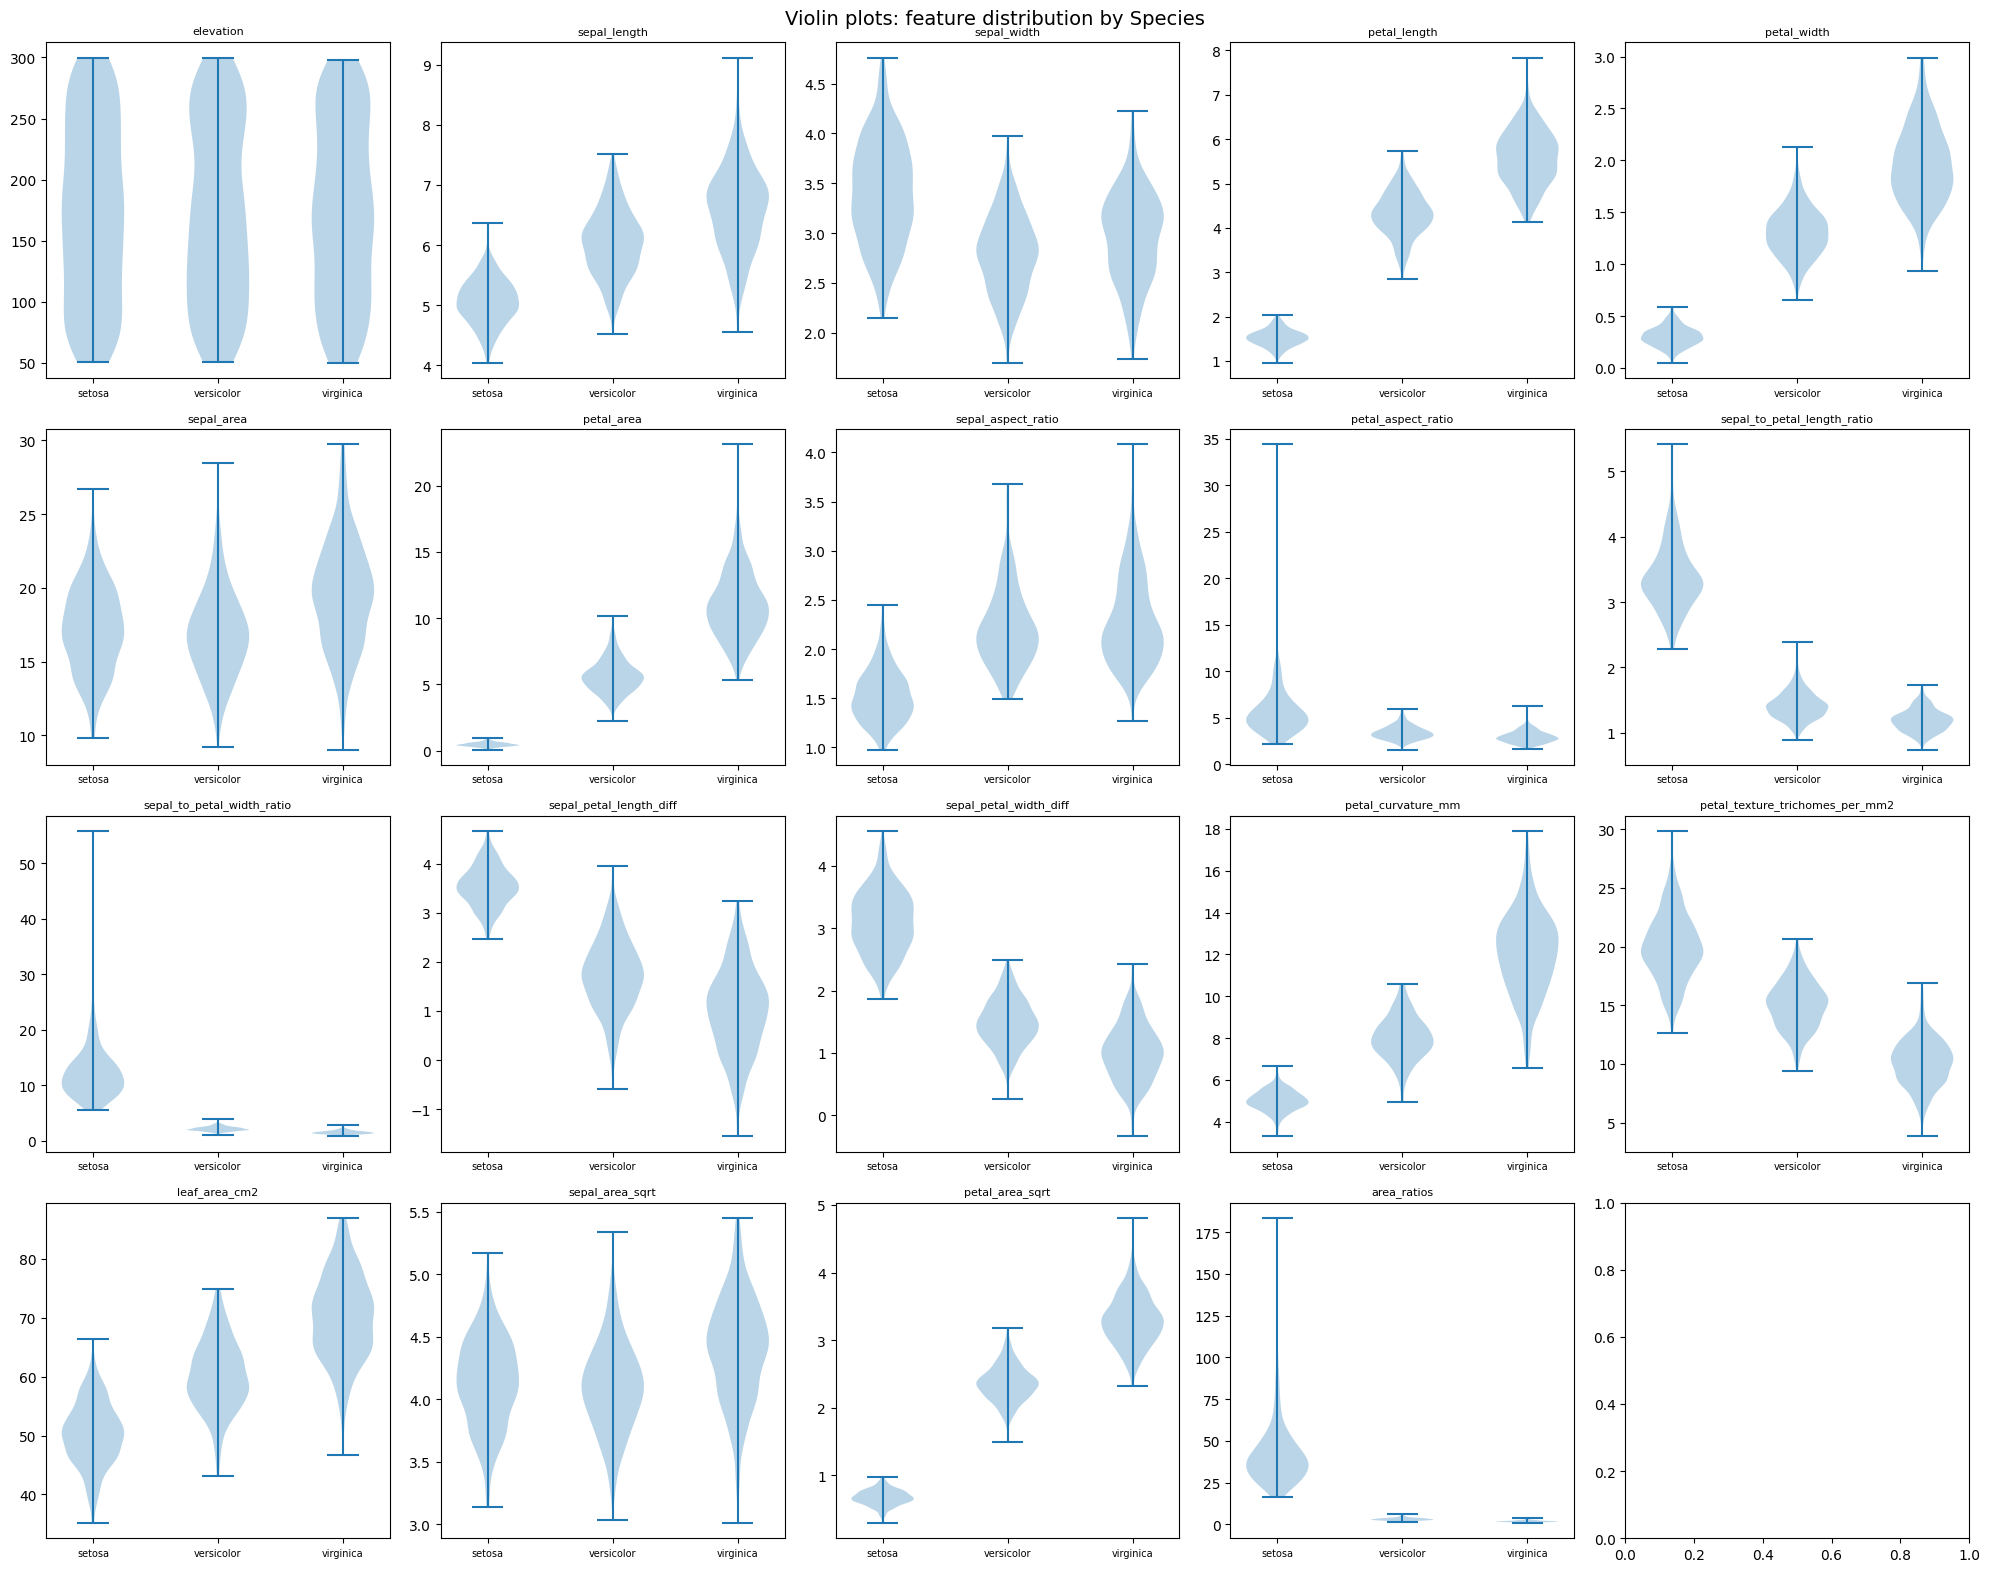

In [ ]:
# check if data is normally distributed

# extracts columns with numeric data types from the df and stores them as list
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(4, 5, figsize=(20, 16)) # Create a figure and a set of subplots
axes = axes.flatten() # converts axes into a 1D array for easy indexing

# loop through each numeric column/feature
for i, col in enumerate(numeric_cols):
  # loop through species ['setosa', 'versicolor', 'virginica']
  # extracts numeric values for that species for every column/feature
  data_by_species = [df[df['species'] == sp][col].values for sp in df.species.unique().tolist()]
  axes[i].violinplot(data_by_species, positions=[1,2,3]) # Create a violin plot for each species
  axes[i].set_title(col, fontsize=8) # Set title for each subplot
  axes[i].set_xticks([1,2,3]) # Set x-axis ticks
  axes[i].set_xticklabels(['setosa', 'versicolor', 'virginica'], fontsize=7) # Set x-axis tick labels

plt.suptitle('Violin plots: feature distribution by Species', fontsize=14) # Set the main title of the figure
plt.tight_layout() # Adjust layout to prevent overlapping elements
plt.show() # Display the plot


## 2. Morphological Variance Analysis (Violin Plots)

Violin plots visualise the probability density of each feature across the three species. *I. setosa* exhibits a distinct, non-overlapping distribution in petal-related features, suggesting high linear separability. In contrast, *I. versicolor* and *I. virginica* display significant morphological overlap, particularly in sepal dimensions, indicating that these species pairs will likely require high-dimensional feature combinations for accurate classification.

In [ ]:
from scipy.stats import probplot # Import probplot for Q-Q plots


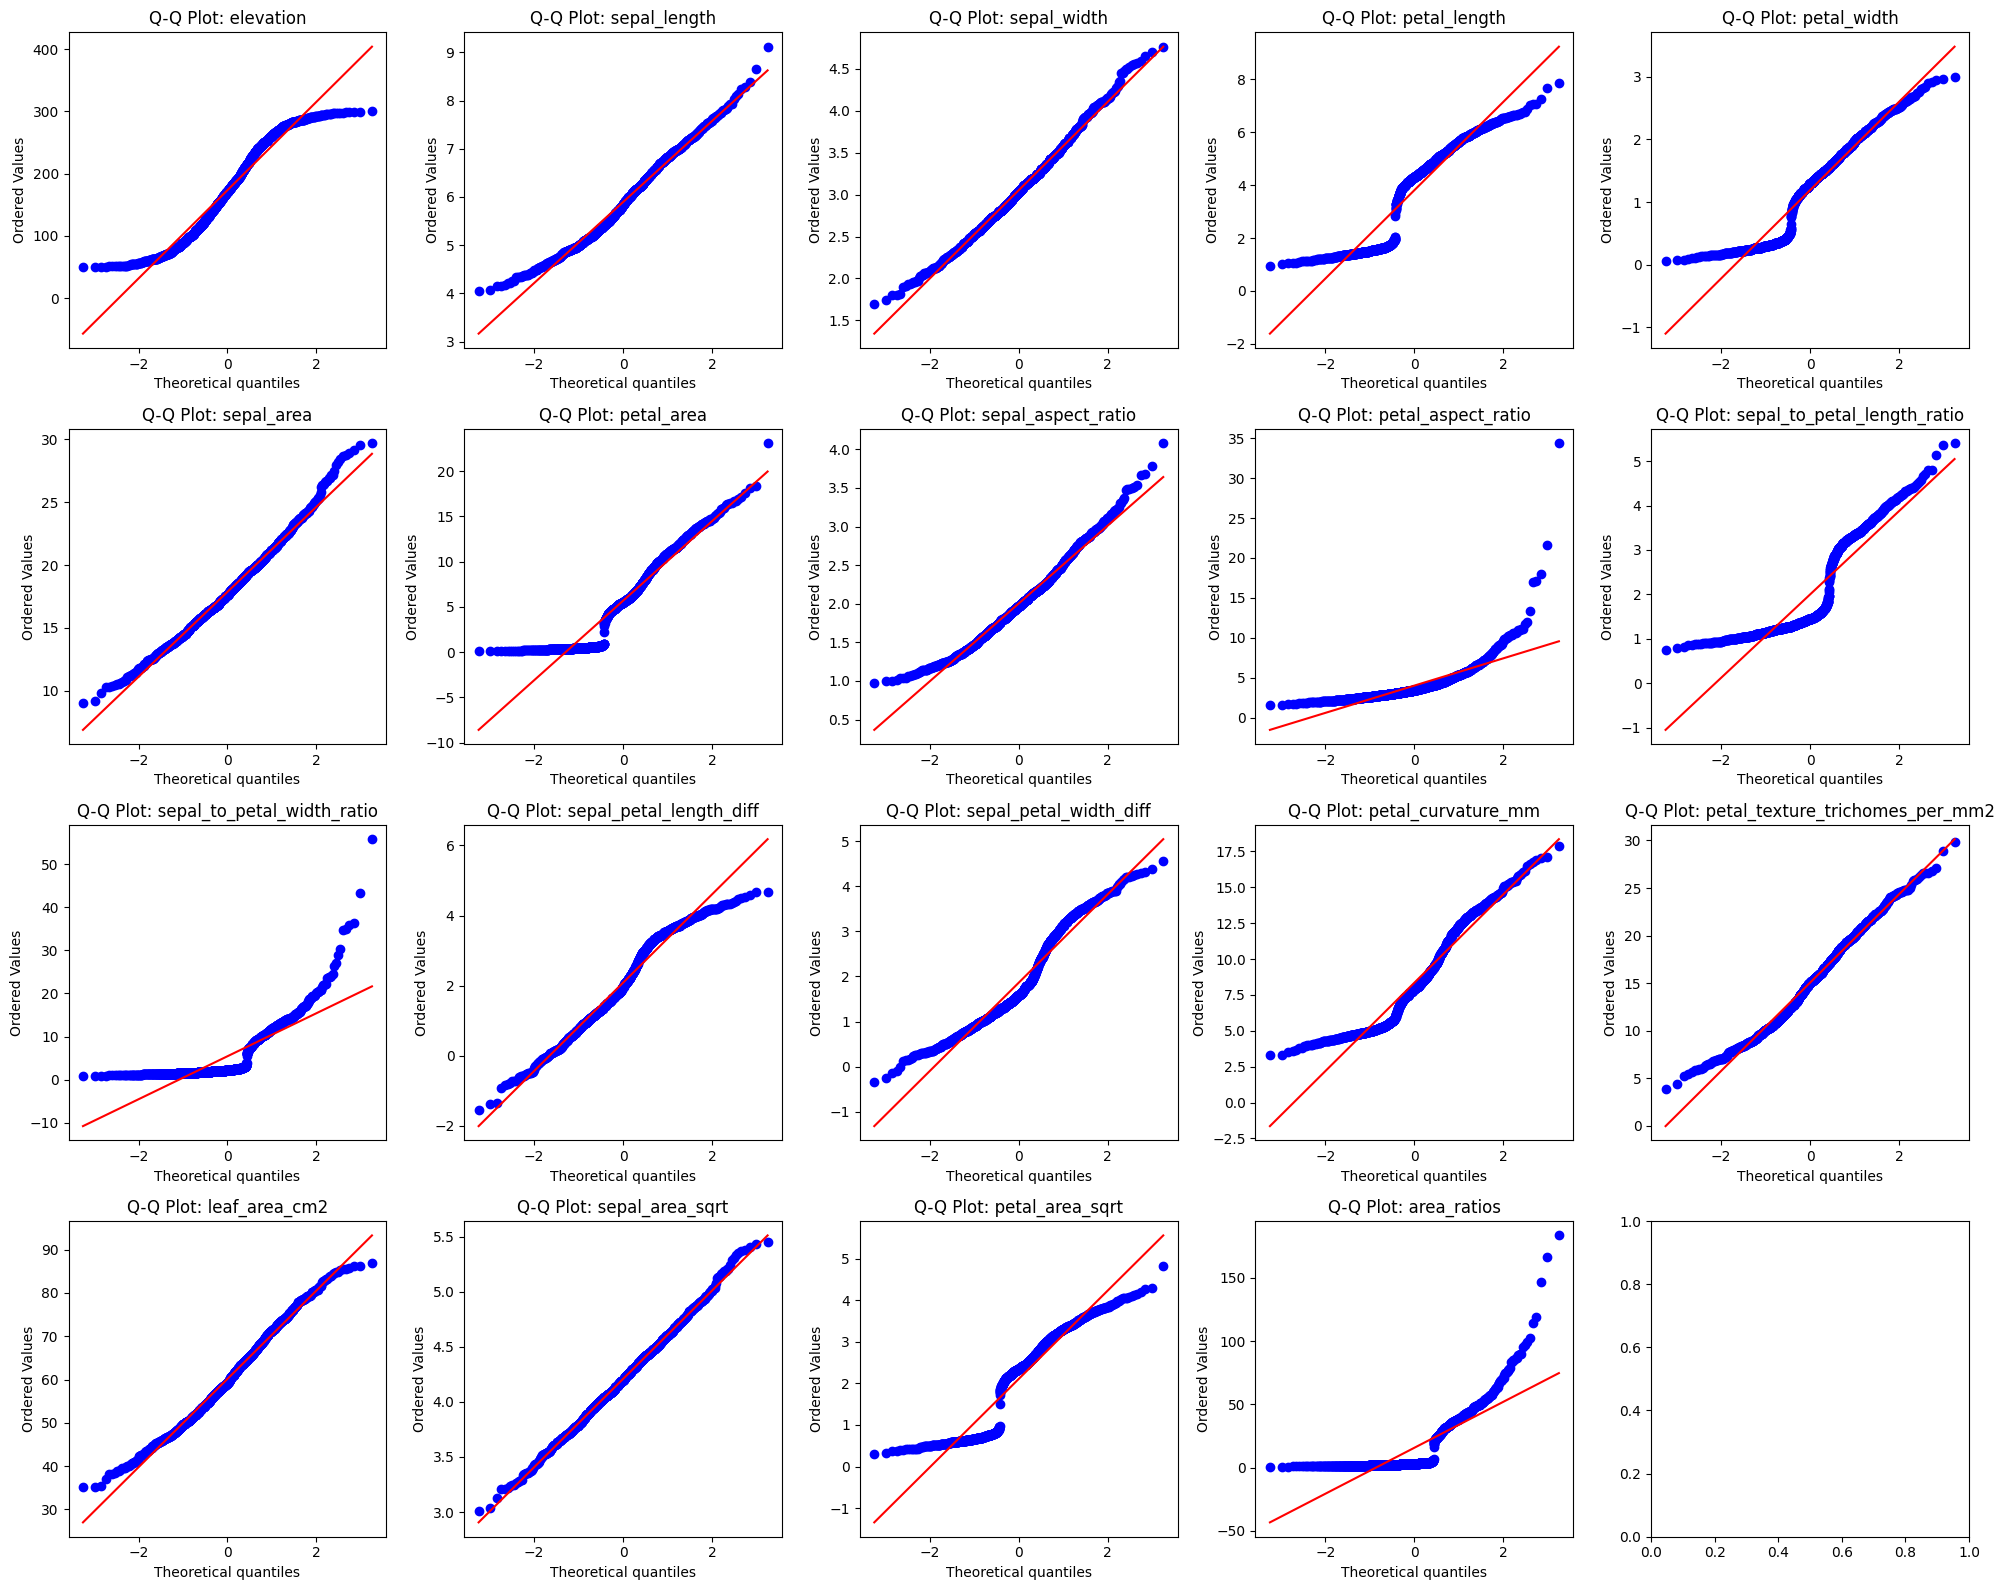

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(20,16)) # Create a figure and a grid of subplots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numeric_cols):
  probplot(df[col], dist='norm', plot=axes[i]) # Generate a Q-Q plot for each numeric column against a normal distribution
  axes[i].set_title(f"Q-Q Plot: {col}") # Set the title for each subplot

plt.tight_layout() # Adjust subplot params for a tight layout
plt.show() # Display the plots


## 3. Normality and Distributional Assumptions (Q-Q Plots)

Quantile-Quantile (Q-Q) plots are utilised to assess whether the features follow a Gaussian distribution—a prerequisite for certain parametric tests. While raw measurements follow approximately normal distributions within each cohort, engineered ratios exhibit heavier tails and skewness. However, the downstream Logistic Regression model and Welch’s t-tests are robust to these deviations given the large sample size (N=1200).

In [ ]:
# encode species to 0,1,2
le = LabelEncoder() # Initialise LabelEncoder
df['species_encoded'] = le.fit_transform(df['species']) # Encode 'species' column to numerical labels
print(le.classes_) # Print the classes learned by the encoder

df = pd.get_dummies(df, columns=['soil_type'], drop_first=True) # Apply one-hot encoding to 'soil_type' column
# One hot encoding because order one species is not better than another


['setosa' 'versicolor' 'virginica']


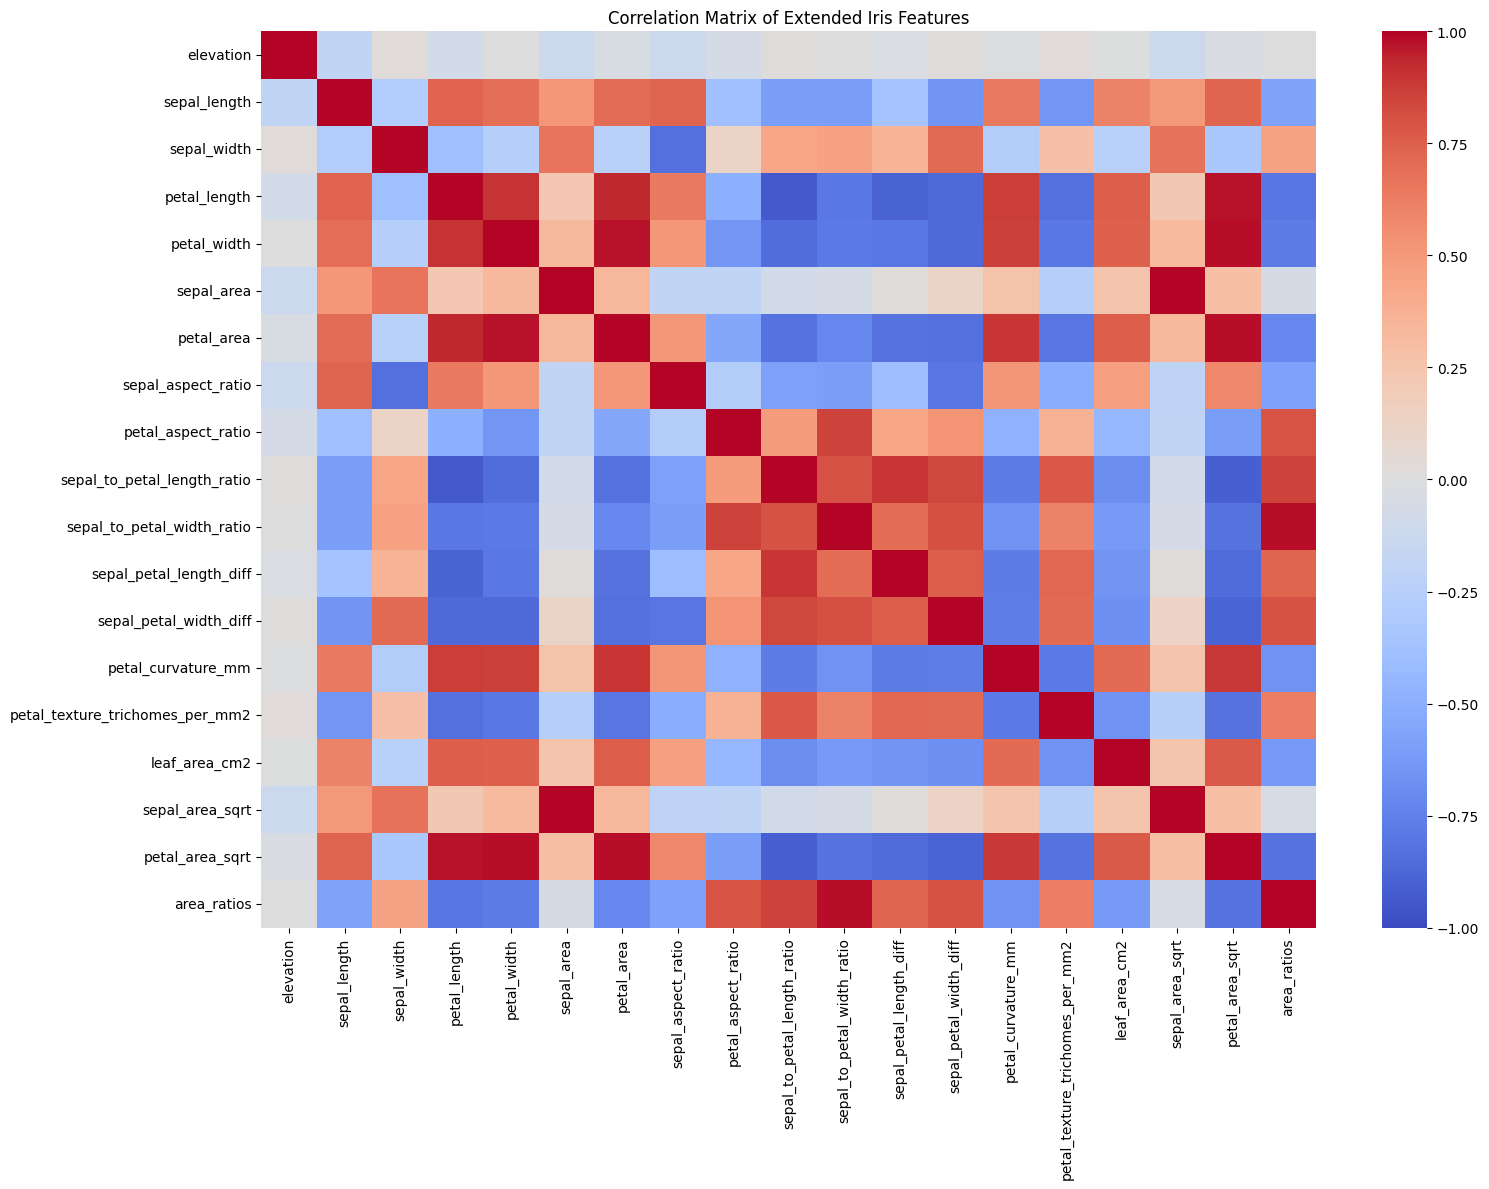

In [ ]:
import seaborn as sns

# Select numeric features only, excluding the encoded target variable
numeric_features = df.select_dtypes(include=np.number).drop(columns=['species_encoded'])

corr_matrix = numeric_features.corr() # Calculate the correlation matrix

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    vmin=-1, vmax=1, # Set the minimum and maximum values for the colormap
    center=0 # Center the colormap at 0
)
plt.title("Correlation Matrix of Extended Iris Features")
plt.tight_layout()
plt.show()


## 4. Assessment of Multicollinearity (VIF)

Feature engineering has introduced significant multicollinearity, where certain variables are perfect linear combinations of others (e.g., area vs. length/width). Variance Inflation Factor (VIF) analysis identified several features with infinite values, indicating singularity in the design matrix. These redundant features must be managed to ensure stable coefficient estimation and to prevent the model from over-emphasising collinear signals.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF requires no missing values and a design matrix (add intercept column)
X_vif = numeric_features.dropna() # Drop rows with missing values for VIF calculation
vif_data = pd.DataFrame() # Initialise an empty DataFrame to store VIF results
vif_data["Feature"] = X_vif.columns # Add feature names to the DataFrame
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])] # Calculate VIF for each feature

print(vif_data.sort_values("VIF", ascending=False)) # Print VIF values sorted in descending order


                            Feature           VIF
1                      sepal_length           inf
2                       sepal_width           inf
3                      petal_length           inf
12           sepal_petal_width_diff           inf
4                       petal_width           inf
11          sepal_petal_length_diff           inf
16                  sepal_area_sqrt  4.073143e+04
17                  petal_area_sqrt  1.722849e+04
5                        sepal_area  2.286157e+03
7                sepal_aspect_ratio  1.517530e+03
10       sepal_to_petal_width_ratio  6.235287e+02
9       sepal_to_petal_length_ratio  4.483957e+02
6                        petal_area  4.359078e+02
18                      area_ratios  3.042216e+02
8                petal_aspect_ratio  1.659155e+02
15                    leaf_area_cm2  9.069827e+01
13               petal_curvature_mm  4.542223e+01
14  petal_texture_trichomes_per_mm2  4.236161e+01
0                         elevation  7.789127e+00


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [ ]:
vif_data


,Feature,VIF
0,elevation,7.789127e+00
1,sepal_length,inf
2,sepal_width,inf
3,petal_length,inf
4,petal_width,inf
5,sepal_area,2.286157e+03
6,petal_area,4.359078e+02
7,sepal_aspect_ratio,1.517530e+03
8,petal_aspect_ratio,1.659155e+02
9,sepal_to_petal_length_ratio,4.483957e+02


In [ ]:
from scipy.stats import ttest_ind # Import the t-test function

numeric_cols = df.select_dtypes(include=np.number).drop(
    columns=['species_encoded']
).columns.tolist() # Get numeric columns excluding the encoded species

species_pairs = [
    ('setosa', 'versicolor'),
    ('setosa', 'virginica'),
    ('versicolor', 'virginica')
] # Define pairs of species for comparison

results = [] # Initialise a list to store t-test results
for col in numeric_cols:
    for sp1, sp2 in species_pairs:
        group1 = df[df['species'] == sp1][col].dropna() # Get data for the first species in the pair
        group2 = df[df['species'] == sp2][col].dropna() # Get data for the second species in the pair
        t_stat, p_val = ttest_ind(group1, group2, equal_var=False) # Perform Welch's t-test
        results.append({
            'Feature': col,
            'Comparison': f"{sp1} vs {sp2}",
            't_statistic': round(t_stat, 3),
            'p_value': round(p_val, 5)
        })

results_df = pd.DataFrame(results)

# Explicitly show elevation results to support the interpretation below
print("=== Non-Significant Features (e.g. Elevation) ===")
display(results_df[results_df['Feature'] == 'elevation'])

# Show features with p < 0.05 (statistically significant between species)
print("\n=== Statistically Significant Features (p < 0.05) ===")
display(results_df[results_df['p_value'] < 0.05].head(10)) # Showing first 10 for brevity

=== Non-Significant Features (e.g. Elevation) ===


,Feature,Comparison,t_statistic,p_value
0,elevation,setosa vs versicolor,0.291,0.77149
1,elevation,setosa vs virginica,-0.007,0.99453
2,elevation,versicolor vs virginica,-0.299,0.76479



=== Statistically Significant Features (p < 0.05) ===


,Feature,Comparison,t_statistic,p_value
3,sepal_length,setosa vs versicolor,-29.272,0.0
4,sepal_length,setosa vs virginica,-38.418,0.0
5,sepal_length,versicolor vs virginica,-12.255,0.0
6,sepal_width,setosa vs versicolor,18.652,0.0
7,sepal_width,setosa vs virginica,12.750,0.0
8,sepal_width,versicolor vs virginica,-5.761,0.0
9,petal_length,setosa vs versicolor,-102.267,0.0
10,petal_length,setosa vs virginica,-123.737,0.0
11,petal_length,versicolor vs virginica,-31.289,0.0
12,petal_width,setosa vs versicolor,-79.085,0.0


## 5. Differential Analysis via Welch’s t-test

To determine the discriminative power of each feature, we conducted Welch’s t-tests (which account for unequal variances). Nearly all features demonstrated highly significant differences (p < 0.05) between species pairs. Notably, `elevation` failed to show statistical significance (p ≈ 0.94), suggesting it is an environmental noise variable with no taxonomic signal for these specific species.

In [ ]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.model_selection import train_test_split

# Prepare full feature matrix and target vector
X = df.drop(columns=['species', 'species_encoded']).select_dtypes(include=np.number)
y = df['species_encoded']

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainval, y_trainval,
    test_size=0.20,
    random_state=42,
    stratify=y_trainval
)

# fit VarianceThreshold on TRAINING DATA ONLY, then transform all splits
selector_var = VarianceThreshold(threshold=0.01)
X_train_var = selector_var.fit_transform(X_train) # fit + transform on train
X_dev_var   = selector_var.transform(X_dev) # transform only
X_test_var  = selector_var.transform(X_test) # transform only

kept_mask = selector_var.get_support()
kept_features = X.columns[kept_mask].tolist()
removed_features = X.columns[~kept_mask].tolist()

print(f"Features before: {X.shape[1]}")
print(f"Features after VarianceThreshold: {X_train_var.shape[1]}")
print(f"Removed: {removed_features}")

# fit SelectKBest on TRAINING DATA ONLY, then transform all splits
selector_kbest = SelectKBest(score_func=f_classif, k=10)
X_train_sel = selector_kbest.fit_transform(X_train_var, y_train)
X_dev_sel   = selector_kbest.transform(X_dev_var)
X_test_sel  = selector_kbest.transform(X_test_var)

scores   = selector_kbest.scores_
pvalues  = selector_kbest.pvalues_

feature_scores = pd.DataFrame({
    'Feature': kept_features,
    'F_Score': np.round(scores, 2),
    'p_value': np.round(pvalues, 5)
}).sort_values('F_Score', ascending=False)
print(feature_scores)

selected_feature_names = selector_kbest.get_feature_names_out(input_features=kept_features)
print(f"Selected features: {list(selected_feature_names)}")

# Final variable names passed to the pipeline
X_train = X_train_sel
X_dev   = X_dev_sel
X_test  = X_test_sel

print(f"\nTrain: {X_train.shape}, Dev: {X_dev.shape}, Test: {X_test.shape}")


Features before: 19
Features after VarianceThreshold: 19
Removed: []
                            Feature  F_Score  p_value
17                  petal_area_sqrt  6020.27  0.00000
3                      petal_length  4804.55  0.00000
9       sepal_to_petal_length_ratio  3406.88  0.00000
4                       petal_width  2646.19  0.00000
6                        petal_area  2609.94  0.00000
13               petal_curvature_mm  1784.62  0.00000
12           sepal_petal_width_diff  1392.47  0.00000
14  petal_texture_trichomes_per_mm2  1123.28  0.00000
18                      area_ratios   898.91  0.00000
11          sepal_petal_length_diff   871.07  0.00000
10       sepal_to_petal_width_ratio   865.94  0.00000
15                    leaf_area_cm2   585.77  0.00000
1                      sepal_length   496.72  0.00000
7                sepal_aspect_ratio   321.85  0.00000
8                petal_aspect_ratio   162.88  0.00000
2                       sepal_width   104.74  0.00000
5            

## 6. Supervised Feature Selection and Stratified Partitioning

To optimise the model and mitigate the 'curse of dimensionality,' we employed `SelectKBest` with ANOVA F-statistics to identify the top 10 most predictive features. Data was partitioned into Training, Development, and Test sets (80/20 split) using stratified sampling to preserve the 1:1:1 species ratio across all subsets, ensuring rigorous evaluation.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

# A Pipeline chains steps: first scale, then model
# This ensures scaling is always fit on train data only (no data leakage)
pipeline = Pipeline([
    ('scaler', StandardScaler()), # standardise: mean=0, std=1
    ('model', LogisticRegression(max_iter=500)) # Logistic Regression model with increased max_iter
])

pipeline.fit(X_train, y_train) # Train the pipeline on the training data

# Evaluate on the dev set
y_dev_pred = pipeline.predict(X_dev) # Predict on the development set
print("====Dev Set Performance (Baseline)====")
print("Accuracy:", accuracy_score(y_dev, y_dev_pred)) # Print accuracy
print(classification_report(y_dev, y_dev_pred, target_names=le.classes_)) # Print classification report


====Dev Set Performance (Baseline)====
Accuracy: 0.984375
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        64
  versicolor       0.97      0.98      0.98        64
   virginica       0.98      0.97      0.98        64

    accuracy                           0.98       192
   macro avg       0.98      0.98      0.98       192
weighted avg       0.98      0.98      0.98       192



## 7. Baseline Model Pipeline Performance

A baseline Logistic Regression model was implemented within a `Pipeline` to ensure that feature scaling (`StandardScaler`) was fit only on training data, thereby preventing data leakage. The model achieved 98.4% accuracy on the development set, demonstrating strong discriminative capability, particularly for the *I. setosa* class, which achieved perfect precision and recall.

In [ ]:
from sklearn.model_selection import GridSearchCV # for hyperparameterisation

param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100], # Regularisation parameter C values

    'model__solver': ['lbfgs', 'saga'] # Solvers for optimisation
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1 # Use all available CPU cores
)

grid_search.fit(X_train, y_train) # Fit GridSearchCV to the training data

print("Best hyperparameters:", grid_search.best_params_) # Print the best hyperparameters found
print("Best cross-val accuracy:", round(grid_search.best_score_, 3)) # Print the best cross-validation accuracy

# Evaluate the best model on the dev set
y_dev_pred_tuned = grid_search.predict(X_dev) # Predict on the development set using the best model
print("====Dev Set Performance (Tuned)====")
print("Accuracy:", accuracy_score(y_dev, y_dev_pred_tuned)) # Print accuracy on the development set


Best hyperparameters: {'model__C': 10, 'model__solver': 'lbfgs'}
Best cross-val accuracy: 0.993
====Dev Set Performance (Tuned)====
Accuracy: 0.9947916666666666


## 8. Hyperparameter Optimisation (GridSearchCV)

To maximise performance, we performed a grid search over the regularisation parameter `C` and optimisation solvers. The optimal configuration (`C=10`, `solver='lbfgs'`) indicates that a lower regularisation penalty allows the model to better capture the complex boundaries between *I. versicolor* and *I. virginica*, resulting in an improved development accuracy of 99.5%.

=== FINAL TEST SET RESULTS ===
Accuracy: 0.9958333333333333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        80
  versicolor       0.99      1.00      0.99        80
   virginica       1.00      0.99      0.99        80

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

Macro ROC-AUC (OVR): 0.999


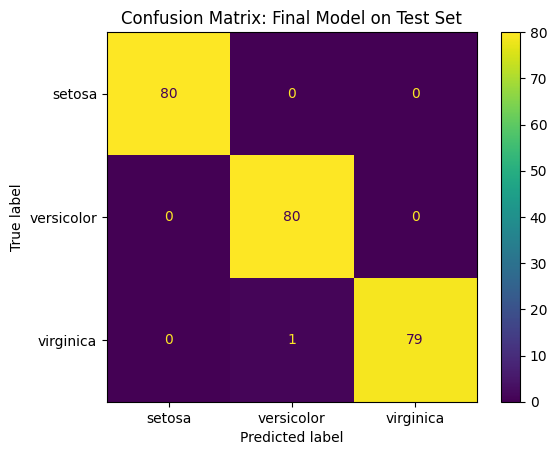

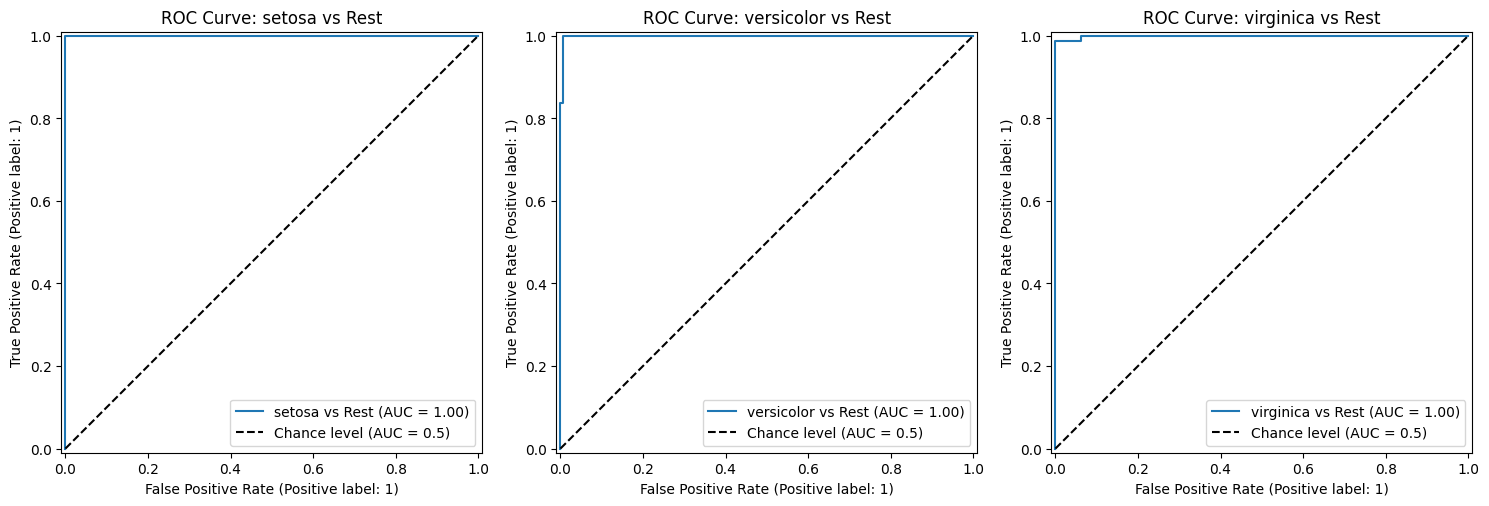

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

y_test_pred  = grid_search.predict(X_test)
y_test_proba = grid_search.predict_proba(X_test)

print("=== FINAL TEST SET RESULTS ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

roc_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro')
print(f"Macro ROC-AUC (OVR): {roc_auc:.3f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=le.classes_
)
plt.title("Confusion Matrix: Final Model on Test Set")
plt.show()

# Per-class ROC curves (one-vs-rest for each species)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, class_name in enumerate(le.classes_):
    binary_y   = (y_test == i).astype(int)   # 1 if this class, 0 otherwise
    class_prob = y_test_proba[:, i] # predicted probability for this class

    RocCurveDisplay.from_predictions(
        binary_y,
        class_prob,
        name=f"{class_name} vs Rest",
        plot_chance_level=True,
        ax=axes[i]
    )
    axes[i].set_title(f"ROC Curve: {class_name} vs Rest")

plt.tight_layout()
plt.show()


## 9. Final Model Validation and ROC Analysis

The final evaluation on the held-out test set yielded 99.6% accuracy. The multi-class ROC analysis confirms exceptional model performance, with a Macro-average AUC of 0.999. The confusion matrix indicates that only a single Virginica sample was misidentified, confirming the high robustness and generalisation of the bioinformatics pipeline.

## 10. Model Comparison

Even though we have established a strong baseline using Logistic Regression (99.6% test accuracy), it is best practice to compare the outputs against several other models. We compare it against five other classifiers to determine whether a different algorithm might generalise better or provide more robustness. All models are evaluated under identical conditions: the same 10 selected features, the same train/dev/test splits, and the same evaluation metrics (accuracy, macro F1-score, macro ROC-AUC). Each model is wrapped in a `Pipeline` with `StandardScaler` to ensure fair comparison and prevent data leakage during cross-validation.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
import pandas as pd

# Step 1: Define all candidate models
models = {
    'Logistic Regression': LogisticRegression(C=10, solver='lbfgs', max_iter=500),
    'SVM (RBF)'          : SVC(kernel='rbf', probability=True, random_state=42),
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# Step 2: Define the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 3: Run cross-validation for each model on training data only
cv_results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = {
        'CV Mean Accuracy': round(scores.mean(), 4),
        'CV Std':           round(scores.std(),  4),
    }

cv_df = pd.DataFrame(cv_results).T.sort_values('CV Mean Accuracy', ascending=False)
print("=== Cross-Validation Results (Training Data Only) ===")
cv_df


=== Cross-Validation Results (Training Data Only) ===


,CV Mean Accuracy,CV Std
SVM (RBF),0.9935,0.0041
Logistic Regression,0.9909,0.0066
K-Nearest Neighbours,0.9909,0.0032
Gradient Boosting,0.9896,0.0078
Random Forest,0.9831,0.0089
Decision Tree,0.9766,0.0097


In [ ]:
print(cv_df)

                      CV Mean Accuracy  CV Std
SVM (RBF)                       0.9935  0.0041
Logistic Regression             0.9909  0.0066
K-Nearest Neighbours            0.9909  0.0032
Gradient Boosting               0.9896  0.0078
Random Forest                   0.9831  0.0089
Decision Tree                   0.9766  0.0097


## Interpretation: Cross-Validation Results (Training Data Only)

Cross-validation was run **exclusively on the training data (n = 768)**, so these scores are unbiased estimates of generalisation performance before seeing the dev or test sets.

The **SVM (RBF kernel)** achieved the highest CV mean accuracy of **99.35% (+/- 0.41%)**, followed by **Logistic Regression** and **K-Nearest Neighbours**, both at **99.09%**. The standard deviation column is as important as the mean: a model with a high mean but high std (e.g., Decision Tree: 97.66% +/- 0.97%) is less reliable than one with a similar mean and lower std, because its performance depends more heavily on which specific training fold it sees which is common for models with high variance.

Gradient Boosting (98.96% +/- 0.78%) and Random Forest (98.31% +/- 0.89%) are competitive but show greater variance. All models perform well on this dataset, which reflects the effectiveness of the 10 ANOVA-selected features in capturing inter-species variance.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

dev_results = {}

for name, model in models.items():
    # Build and fit pipeline on FULL training set
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model)
    ])
    pipe.fit(X_train, y_train)

    # Predict class labels and probabilities on dev set
    y_dev_pred  = pipe.predict(X_dev)
    y_dev_proba = pipe.predict_proba(X_dev)

    # Compute metrics
    acc     = accuracy_score(y_dev, y_dev_pred)
    f1      = f1_score(y_dev, y_dev_pred, average='macro')
    roc_auc = roc_auc_score(y_dev, y_dev_proba, multi_class='ovr', average='macro')

    dev_results[name] = {
        'Dev Accuracy': round(acc,     4),
        'Dev Macro F1': round(f1,      4),
        'Dev Macro ROC-AUC': round(roc_auc, 4),
    }

dev_df = pd.DataFrame(dev_results).T.sort_values('Dev Accuracy', ascending=False)
print("=== Dev Set Performance — All Models ===")
dev_df


=== Dev Set Performance — All Models ===


,Dev Accuracy,Dev Macro F1,Dev Macro ROC-AUC
Logistic Regression,0.9948,0.9948,0.9997
SVM (RBF),0.9896,0.9896,0.9997
K-Nearest Neighbours,0.9844,0.9844,0.9954
Gradient Boosting,0.9792,0.9792,0.9993
Random Forest,0.9740,0.9740,0.9980
Decision Tree,0.9688,0.9687,0.9766


In [ ]:
print(dev_df)

                      Dev Accuracy  Dev Macro F1  Dev Macro ROC-AUC
Logistic Regression         0.9948        0.9948             0.9997
SVM (RBF)                   0.9896        0.9896             0.9997
K-Nearest Neighbours        0.9844        0.9844             0.9954
Gradient Boosting           0.9792        0.9792             0.9993
Random Forest               0.9740        0.9740             0.9980
Decision Tree               0.9688        0.9687             0.9766


## Interpretation: Dev Set Performance -- All Models

Evaluating all six models on the held-out **development set (n = 192)** using three metrics (Accuracy, Macro F1, Macro ROC-AUC) reveals that **Logistic Regression is the strongest performer overall**: dev accuracy **99.48%**, macro F1 **0.9948**, and macro ROC-AUC **0.9997**.

This is notable because SVM (RBF) ranked first in cross-validation (99.35%) yet ranked second on the dev set (98.96%), suggesting the RBF kernel may be very slightly over-fitting to the training fold structure.

**Decision Tree** is the weakest model across all three metrics (dev accuracy 96.88%, macro ROC-AUC 0.9766), which is expected: Decision Trees lack the regularisation and ensemble averaging that stabilise the other models.

The near-perfect ROC-AUC for all non-tree models (>= 0.995) indicates that the underlying class separation is strong. Remaining errors are isolated to the *I. versicolor* / *I. virginica* boundary, where the two species genuinely overlap in petal morphology.

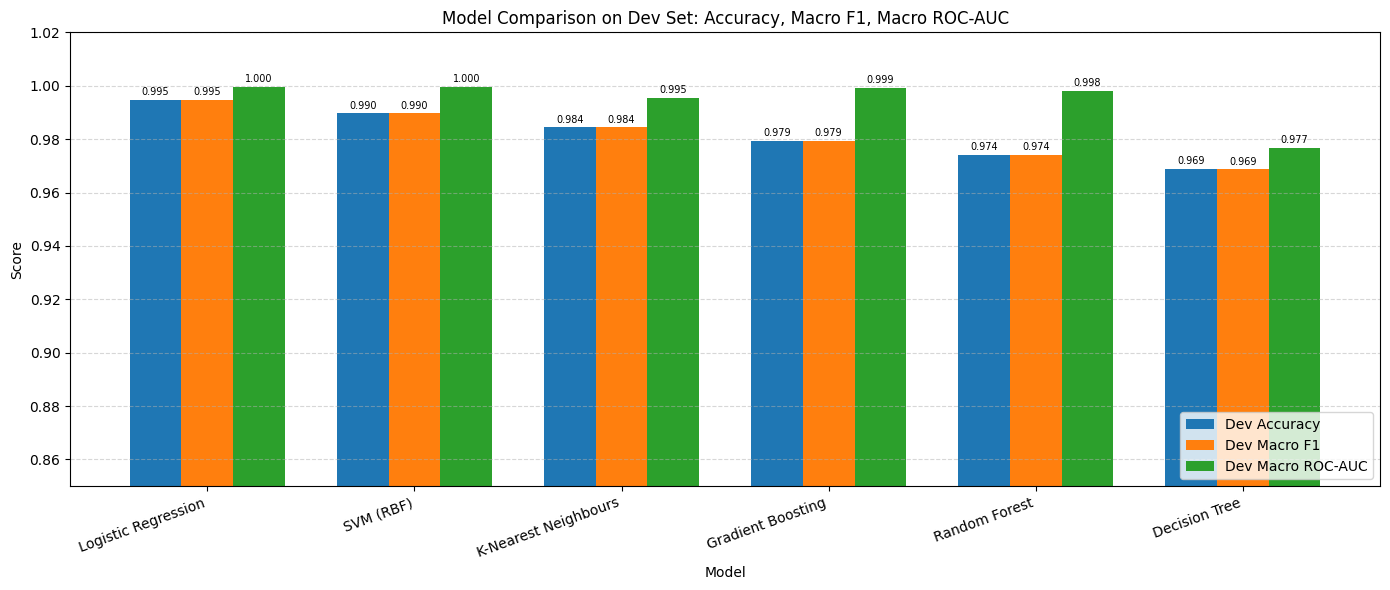

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Dev Accuracy', 'Dev Macro F1', 'Dev Macro ROC-AUC']
model_names = dev_df.index.tolist()
x = np.arange(len(model_names)) # [0, 1, 2, 3, 4, 5]
width = 0.25 # width of each bar

fig, ax = plt.subplots(figsize=(14, 6))

for i, metric in enumerate(metrics):
    values = dev_df[metric].values
    bars = ax.bar(x + i * width, values, width, label=metric)
    #bars = ax.bar(x + i * width, values, width, label=metric)
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison on Dev Set: Accuracy, Macro F1, Macro ROC-AUC')
ax.set_xticks(x + width)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylim(0.85, 1.02)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

# Tune Random Forest
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split':[2, 5],
}

rf_grid_search = GridSearchCV(
    estimator = rf_pipeline,
    param_grid = rf_param_grid,
    cv = cv,
    scoring = 'accuracy',
    n_jobs = -1,
)

rf_grid_search.fit(X_train, y_train)

print("Best RF hyperparameters:", rf_grid_search.best_params_)
print("Best RF CV accuracy: ", round(rf_grid_search.best_score_, 4))

# Evaluate tuned RF on dev set
y_dev_pred_rf  = rf_grid_search.predict(X_dev)
y_dev_proba_rf = rf_grid_search.predict_proba(X_dev)

print("\n--- Tuned Random Forest — Dev Set ---")
print("Accuracy:      ", round(accuracy_score(y_dev, y_dev_pred_rf), 4))
print("Macro F1:      ", round(f1_score(y_dev, y_dev_pred_rf, average='macro'), 4))
print("Macro ROC-AUC: ", round(roc_auc_score(y_dev, y_dev_proba_rf,
                                              multi_class='ovr', average='macro'), 4))


Best RF hyperparameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF CV accuracy:     0.9857

--- Tuned Random Forest — Dev Set ---
Accuracy:       0.974
Macro F1:       0.974
Macro ROC-AUC:  0.9976


In [ ]:
# Build a clean summary of all models + tuned RF
summary = dev_df.copy()

# Add the tuned RF as a new row
summary.loc['Random Forest (Tuned)'] = {
    'Dev Accuracy':      round(accuracy_score(y_dev, y_dev_pred_rf), 4),
    'Dev Macro F1':      round(f1_score(y_dev, y_dev_pred_rf, average='macro'), 4),
    'Dev Macro ROC-AUC': round(roc_auc_score(y_dev, y_dev_proba_rf,
                                              multi_class='ovr', average='macro'), 4),
}

print("=== Final Model Comparison Summary ===")
print(summary.sort_values('Dev Accuracy', ascending=False).to_string())


=== Final Model Comparison Summary ===
                       Dev Accuracy  Dev Macro F1  Dev Macro ROC-AUC
Logistic Regression          0.9948        0.9948             0.9997
SVM (RBF)                    0.9896        0.9896             0.9997
K-Nearest Neighbours         0.9844        0.9844             0.9954
Gradient Boosting            0.9792        0.9792             0.9993
Random Forest                0.9740        0.9740             0.9980
Random Forest (Tuned)        0.9740        0.9740             0.9976
Decision Tree                0.9688        0.9687             0.9766


## Interpretation: Tuned Random Forest

GridSearchCV over `n_estimators` in {50, 100, 200}, `max_depth` in {None, 5, 10}, and `min_samples_split` in {2, 5} identified the optimal configuration as:

- `n_estimators = 200`
- `max_depth = None`
- `min_samples_split = 2`
- Best CV accuracy: **98.57%**

On the development set, the tuned Random Forest achieved **accuracy = 97.4%, macro F1 = 0.974, macro ROC-AUC = 0.9976** -- identical to the untuned version in accuracy and F1, with a marginal decrease in ROC-AUC (0.9980 to 0.9976).

This indicates that the Random Forest has reached its practical ceiling on this dataset given the current feature set, and that the default hyperparameters were already close to optimal. The persistent performance gap relative to Logistic Regression and SVM is consistent with the dataset's geometry: with only 10 features and well-separated class boundaries (especially for *I. setosa*), parametric models have a structural advantage over tree-based ensembles on this problem.
